# Naïve DSA Unit — Paprika Disease Severity Analysis

Implements the **Naïve DSA unit** from Section 4.2.2 of the DIANA paper.

### Two-stage naïve pipeline (Figure 6)
```
Image
  → [Frozen DDL]          — produces bounding boxes + class labels
  → Crop & Resize 256×256 — one crop per detected box
  → [DSA]                 — pixel-wise severity stage prediction
  → Remap to original     — paste masks back onto full image
  → Integration Unit      — generate descriptive phrases
```

**Key difference from DIANA (proposed approach):** DDL and DSA are trained
completely independently. No shared features, no joint gradients.
That is the defining limitation of the naïve approach.

### Pest-only rule (Section 5.5)
When the DDL detects **only** `snails_and_slugs` or `spider_mite`, the DSA
is skipped entirely — pests have no severity stages.

### Expected splits (70 / 10 / 20 — Section 4.3)
These are *instance* counts from Table 2. Actual image counts are printed
at runtime in Cell 3.

| Class | Train (~70%) | Val (~10%) | Test (~20%) |
|---|---|---|---|
| blossom_end_rot | 226 | 32 | 65 |
| graymold | 135 | 19 | 40 |
| powdermildew | 156 | 22 | 45 |
| spotting_disease | 200 | 28 | 58 |
| **TOTAL** | **718** | **102** | **206** |

## Cell 1 — Imports

In [1]:
!pip install git+https://github.com/facebookresearch/detectron2.git

import os, json, glob, random, copy
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# Detectron2 — only needed to load the frozen DDL
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-8r810h8x
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-8r810h8x
  Resolved https://github.com/facebookresearch/detectron2.git to commit b599f139756bd3646a26a909caf86a1a159e53a7
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.4 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111489 sha256=1adc0c807d690d5b2a9eaa9902ddf74a01702a777902d7a78955d7502cead2f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-iblep4km/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=c7df959beb9036759b1e48ffe

## Cell 2 — Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
RAW_DATA_ROOT = '/kaggle/input/datasets/tijesu26/paprika-dataset/raw_Data'
DDL_WEIGHTS   = '/kaggle/input/notebooks/tijesu26/paprika-ddl-implementation/output/naive_ddl/model_final.pth'
DSA_OUTPUT    = '/kaggle/working/output/naive_dsa'
os.makedirs(DSA_OUTPUT, exist_ok=True)

# ── Class names (must match DDL notebook exactly) ──────────────────────────
CLASS_NAMES = [
    'blossom_end_rot',
    'graymold',
    'powdery_mildew',
    'spider_mite',
    'spotting_disease',
    'snails_and_slugs',
]
PEST_CLASSES = {'snails_and_slugs', 'spider_mite'}   # no severity stages

# ── Severity stage map ─────────────────────────────────────────────────────
# 0 = background, 1-11 = the 11 named severity stages from Table 2 / Figure 1
# Labels come directly from the LabelMe JSON files in raw_Data
SEVERITY_MAP = {
    'background': 0,
    'br1': 1, 'br2': 2, 'br3': 3,           # blossom end rot
    'gm1': 4, 'gm2': 5,                     # gray mold
    'pm1': 6, 'pm2': 7,                     # powdery mildew
    'cp1': 8, 'cp2': 9, 'cp3': 10, 'cp4': 11,  # cercospora / spotting
}
NSS = len(SEVERITY_MAP)  # 12 channels: background + 11 stages

# ── Training hyper-parameters (Table 3, scaled for Kaggle free tier) ───────
CROP_SIZE    = 256      # fixed crop size Section 4.2.2
BATCH_SIZE   = 8        # paper uses larger batches; 8 fits Kaggle T4
LR           = 0.001
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
NUM_EPOCHS   = 400       # paper trains 100K iters; reduce for Kaggle
RANDOM_SEED  = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print('Config loaded.')

Config loaded.


## Cell 3 — Scan dataset and build file list

Walks every subfolder in `raw_Data`, pairs each `.jpg` with its `.json`,
and prints the actual image count per class before splitting.

In [3]:
def scan_raw_data(root):
    """
    Returns a list of dicts:
        {'img_path': str, 'json_path': str, 'class_name': str}
    Only includes files where BOTH .jpg and .json exist.
    """
    records = []
    for class_folder in sorted(os.listdir(root)):
        folder_path = os.path.join(root, class_folder)
        if not os.path.isdir(folder_path):
            continue
        jpg_files = glob.glob(os.path.join(folder_path, '*.jpg'))
        for jpg in sorted(jpg_files):
            json_path = os.path.splitext(jpg)[0] + '.json'
            if os.path.exists(json_path):
                records.append({
                    'img_path':   jpg,
                    'json_path':  json_path,
                    'class_name': class_folder,
                })
    return records


all_records = scan_raw_data(RAW_DATA_ROOT)

# ── Print counts ───────────────────────────────────────────────────────────
from collections import Counter
counts = Counter(r['class_name'] for r in all_records)
total  = len(all_records)

print(f'Total paired image+json files found: {total}')
print()
print(f'{"Class":<25} {"Total":>7} {"Train(70%)":>10} {"Val(10%)":>9} {"Test(20%)":>9}')
print('-' * 65)
for cls, n in sorted(counts.items()):
    tr = int(n * 0.70)
    va = int(n * 0.10)
    te = n - tr - va
    print(f'{cls:<25} {n:>7,} {tr:>10,} {va:>9,} {te:>9,}')
print('-' * 65)
tr_t = int(total*0.70); va_t = int(total*0.10); te_t = total-tr_t-va_t
print(f'{"TOTAL":<25} {total:>7,} {tr_t:>10,} {va_t:>9,} {te_t:>9,}')

Total paired image+json files found: 1026

Class                       Total Train(70%)  Val(10%) Test(20%)
-----------------------------------------------------------------
blossom_end_rot               323        226        32        65
graymold                      194        135        19        40
powderymildew                 223        156        22        45
spotting_disease              286        200        28        58
-----------------------------------------------------------------
TOTAL                       1,026        718       102       206


In [4]:
list_of_files = glob.glob(os.path.join("/kaggle/input/datasets/tijesu26/paprika-dataset/test_data", "**", '*.jpg'), recursive=True)
len(list_of_files)

961

## Cell 4 — Split into train / val / test

Splits are done **per class** (stratified) so each split has a
proportional representation of every disease class.

In [5]:
def split_records(records, train_ratio=0.70, val_ratio=0.10, seed=42):
    """
    Stratified split per class.
    Returns train_list, val_list, test_list.
    """
    from collections import defaultdict
    by_class = defaultdict(list)
    for r in records:
        by_class[r['class_name']].append(r)

    train_all, val_all, test_all = [], [], []
    for cls, items in by_class.items():
        random.Random(seed).shuffle(items)
        n      = len(items)
        n_tr   = int(n * train_ratio)
        n_va   = int(n * val_ratio)
        train_all.extend(items[:n_tr])
        val_all.extend(items[n_tr:n_tr + n_va])
        test_all.extend(items[n_tr + n_va:])

    return train_all, val_all, test_all


train_records, val_records, test_records = split_records(all_records)

print(f'Train : {len(train_records):,} images')
print(f'Val   : {len(val_records):,} images')
print(f'Test  : {len(test_records):,} images')

Train : 717 images
Val   : 101 images
Test  : 208 images


## Cell 5 — LabelMe JSON → pixel mask

Each `.json` file stores polygon annotations in LabelMe format.
We convert every polygon to a filled pixel mask using the `SEVERITY_MAP`.
Labels not in `SEVERITY_MAP` are treated as background (0).

In [6]:
def labelme_json_to_mask(json_path, height, width):
    """
    Converts a LabelMe polygon JSON into a (H, W) uint8 mask.
    Each pixel value = severity stage index from SEVERITY_MAP.
    Pixels not covered by any polygon = 0 (background).
    """
    with open(json_path, 'r') as f:
        data = json.load(f)

    mask = np.zeros((height, width), dtype=np.uint8)
    # print(len(data.get('shapes', [])))
    for shape in data.get('shapes', []):
        label      = shape['label'].strip().lower()
        stage_idx  = SEVERITY_MAP.get(label, 0)   # unknown labels → background
        if stage_idx == 0:
            continue  # skip background polygons

        points = np.array(shape['points'], dtype=np.int32)

        # Clamp points to image bounds (avoids out-of-range errors)
        points[:, 0] = np.clip(points[:, 0], 0, width  - 1)
        points[:, 1] = np.clip(points[:, 1], 0, height - 1)

        cv2.fillPoly(mask, [points], color=int(stage_idx))

    return mask


# ── Quick sanity check on the example file shown in the question ───────────
example_json = os.path.join(
    RAW_DATA_ROOT,
    'blossom_end_rot',
    '0_blossom_end_rot_0002.json'
)
if os.path.exists(example_json):
    test_mask = labelme_json_to_mask(example_json, 256, 256)
    unique    = np.unique(test_mask)
    print(f'Unique stage indices in example mask: {unique}')
    print(f'Stage names: {[k for k,v in SEVERITY_MAP.items() if v in unique]}')
else:
    print('Example JSON not found — will work fine on Kaggle.')

Unique stage indices in example mask: [0 3]
Stage names: ['background', 'br3']


## Cell 6 — PyTorch Dataset

For the **naïve** pipeline, the DSA is trained on **ground-truth crops**
taken from the raw images using the bounding boxes in the JSON annotations,
**not** from DDL predictions.

Why? Because during training we want clean signal — if we used DDL boxes,
any DDL errors would corrupt the DSA's training data. At **inference** time
(Cell 11) the frozen DDL's boxes are used, exactly as the paper describes.

In [7]:
class PaprikaDSADataset(Dataset):
    """
    Returns (crop_tensor, mask_tensor) pairs.

    For each image:
      1. Load the full image and build the full-resolution pixel mask.
      2. Derive a tight bounding box from all annotated polygons in the JSON.
      3. Crop both image and mask to that box.
      4. Resize to CROP_SIZE × CROP_SIZE (256×256) — Section 4.2.2.

    Pest-only images (no severity-stage annotations) are skipped.
    """

    def __init__(self, records, crop_size=256, augment=False):
        self.crop_size = crop_size
        self.augment   = augment
        # Keep only records that have at least one non-background stage
        self.samples   = self._filter(records)
        print(f'  Dataset size after filtering pest-only images: {len(self.samples):,}')

    def _filter(self, records):
        """Drop images whose class has no severity stages (pests)."""
        kept = []
        for r in records:
            # Quick check: if class folder name implies pest, skip
            cls = r['class_name'].lower()
            if any(p in cls for p in ('snail', 'slug', 'spider', 'mite')):
                continue
            kept.append(r)
        return kept

    def _get_bbox_from_json(self, data, h, w):
        """Returns (x1, y1, x2, y2) tight box around all polygons."""
        all_pts = []
        for shape in data.get('shapes', []):
            all_pts.extend(shape['points'])
        if not all_pts:
            return 0, 0, w, h  # full image fallback
        pts = np.array(all_pts)
        x1  = max(0, int(pts[:, 0].min()))
        y1  = max(0, int(pts[:, 1].min()))
        x2  = min(w, int(pts[:, 0].max()) + 1)
        y2  = min(h, int(pts[:, 1].max()) + 1)
        if x2 <= x1 or y2 <= y1:   # degenerate box fallback
            return 0, 0, w, h
        return x1, y1, x2, y2

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        record   = self.samples[idx]
        img_bgr  = cv2.imread(record['img_path'])
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w     = img_rgb.shape[:2]

        with open(record['json_path'], 'r') as f:
            ann_data = json.load(f)

        # Build full-res mask then crop
        mask          = labelme_json_to_mask(record['json_path'], h, w)
        x1, y1, x2, y2 = self._get_bbox_from_json(ann_data, h, w)

        img_crop  = img_rgb[y1:y2, x1:x2]
        mask_crop = mask[y1:y2, x1:x2]

        # Resize to 256×256 — no aspect-ratio preservation (Section 4.2.2)
        img_resized  = cv2.resize(img_crop,  (self.crop_size, self.crop_size))
        mask_resized = cv2.resize(mask_crop, (self.crop_size, self.crop_size),
                                  interpolation=cv2.INTER_NEAREST)

        # Optional augmentation (horizontal flip only — matches Table 4)
        if self.augment and random.random() < 0.9:
            img_resized  = cv2.flip(img_resized, 1)
            mask_resized = cv2.flip(mask_resized, 1)

        # (H, W, 3) uint8 → (3, H, W) float32 in [0, 1]
        img_t  = torch.from_numpy(
            img_resized.transpose(2, 0, 1)).float() / 255.0
        mask_t = torch.from_numpy(mask_resized).long()

        return img_t, mask_t


print('Building datasets...')
train_dataset = PaprikaDSADataset(train_records, augment=True)
val_dataset   = PaprikaDSADataset(val_records,   augment=False)
test_dataset  = PaprikaDSADataset(test_records,  augment=False)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f'Train loader: {len(train_loader):,} batches')
print(f'Val   loader: {len(val_loader):,} batches')
print(f'Test  loader: {len(test_loader):,} batches')

Building datasets...
  Dataset size after filtering pest-only images: 717
  Dataset size after filtering pest-only images: 101
  Dataset size after filtering pest-only images: 208
Train loader: 90 batches
Val   loader: 13 batches
Test  loader: 26 batches


## Cell 7 — DSA Model

Encoder-decoder with SE-MobileNetV2-style blocks, skip connections,
and a parallel dilation convolution (PDC) bottleneck.
Matches Section 4.1.2 / 4.2.2 and Table 3 (Mseg=2, Nss=11).

In [8]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation (Hu et al., 2018)."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, channels // reduction), channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c = x.shape[:2]
        w    = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * w


class SEMobileNetV2Block(nn.Module):
    """Inverted residual + SE — the basic unit throughout the DSA encoder/decoder."""
    def __init__(self, in_ch, out_ch, stride=1, expand=6):
        super().__init__()
        mid = in_ch * expand
        self.conv = nn.Sequential(
            # Point-wise expand
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU6(inplace=True),
            # Depth-wise
            nn.Conv2d(mid, mid, 3, stride=stride, padding=1,
                      groups=mid, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU6(inplace=True),
            # Point-wise project
            nn.Conv2d(mid, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.se       = SEBlock(out_ch)
        self.shortcut = (
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
            if in_ch != out_ch or stride != 1 else nn.Identity()
        )

    def forward(self, x):
        return F.relu(self.se(self.conv(x)) + self.shortcut(x))


class PDCBottleneck(nn.Module):
    """Parallel Dilation Convolutions — aggregates multi-scale context."""
    def __init__(self, channels):
        super().__init__()
        # Three parallel branches at dilation 1, 2, 4
        self.d1 = nn.Conv2d(channels, channels, 3, padding=1,  dilation=1)
        self.d2 = nn.Conv2d(channels, channels, 3, padding=2,  dilation=2)
        self.d4 = nn.Conv2d(channels, channels, 3, padding=4,  dilation=4)
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, x):
        return F.relu(self.bn(self.d1(x) + self.d2(x) + self.d4(x)))


class NaiveDSA(nn.Module):
    """
    Naïve DSA encoder-decoder (Section 4.2.2 / Figure 4 decoder branch).

    Input:  (B, 3,   256, 256)  — RGB crop resized from DDL box
    Output: (B, NSS, 256, 256)  — per-pixel severity stage logits

    NSS = 12  (background + 11 severity stages, Table 3)
    """
    def __init__(self, nss=NSS):
        super().__init__()
        # ── Encoder (4 stages, each halves spatial resolution) ──────────────
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            SEBlock(32),
        )  # 256→128
        self.enc2 = nn.Sequential(
            SEMobileNetV2Block(32, 64, stride=2)
        )  # 128→64
        self.enc3 = nn.Sequential(
            SEMobileNetV2Block(64, 128, stride=2)
        )  # 64→32
        self.enc4 = nn.Sequential(
            SEMobileNetV2Block(128, 256, stride=2)
        )  # 32→16

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.pdc = PDCBottleneck(256)

        # ── Decoder (4 stages, each doubles spatial resolution) ──────────────
        # Each decoder block receives: upsampled prev + skip from encoder
        self.dec4 = SEMobileNetV2Block(256 + 128, 128)  # 16→32
        self.dec3 = SEMobileNetV2Block(128 + 64,  64)   # 32→64
        self.dec2 = SEMobileNetV2Block(64  + 32,  32)   # 64→128
        # Original: self.dec1 = SEMobileNetV2Block(32, 32)
        # Fix: 32 channels from dec2 + 3 channels from the raw input image (x) skip connection
        self.dec1 = SEMobileNetV2Block(32+3,         32)   # 128→256

        # ── Segmentation head: Mseg=2 conv layers (Table 3) ─────────────────
        self.seg_head = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, nss, 3, padding=1),
        )

    def _up(self, x, target):
        """Bilinear upsample x to match spatial size of target."""
        return F.interpolate(x, size=target.shape[2:],
                             mode='bilinear', align_corners=False)

    def forward(self, x):
        e1 = self.enc1(x)           # (B,  32, 128, 128)
        e2 = self.enc2(e1)          # (B,  64,  64,  64)
        e3 = self.enc3(e2)          # (B, 128,  32,  32)
        e4 = self.enc4(e3)          # (B, 256,  16,  16)

        b  = self.pdc(e4)           # (B, 256,  16,  16)

        d  = self.dec4(torch.cat([self._up(b, e3),  e3], dim=1))  # →32
        d  = self.dec3(torch.cat([self._up(d, e2),  e2], dim=1))  # →64
        d  = self.dec2(torch.cat([self._up(d, e1),  e1], dim=1))  # →128
        # Original: d = self.dec1(self._up(d, x))
        # Fix: Upsample d to 256x256, then concatenate with x (256x256)
        d_up = self._up(d, x)
        d  = self.dec1(torch.cat([d_up, x], dim=1))               # →256

        return self.seg_head(d)     # (B, NSS, 256, 256)


dsa_model = NaiveDSA(nss=NSS).to(DEVICE)
total_params = sum(p.numel() for p in dsa_model.parameters() if p.requires_grad)
print(f'DSA model parameters: {total_params:,}')

# Smoke test
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(DEVICE)
    out   = dsa_model(dummy)
    print(f'Output shape: {out.shape}')  # expect (2, 12, 256, 256)

DSA model parameters: 3,930,970
Output shape: torch.Size([2, 12, 256, 256])


## Cell 8 — Focal Tversky Loss

From Table 3: α=0.3, β=0.7, γ=4.
Higher β means the loss penalises **false negatives more** than false
positives — important because disease regions are small relative to background.

In [9]:
class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky Loss (Table 3: α=0.3, β=0.7, γ=4).

    Tversky index = TP / (TP + α·FP + β·FN)
    Loss          = (1 - Tversky)^γ

    Computed per-class then averaged (multi-class version).
    """
    def __init__(self, alpha=0.3, beta=0.7, gamma=4, smooth=1e-6,
                 ignore_background=True):
        super().__init__()
        self.alpha             = alpha
        self.beta              = beta
        self.gamma             = gamma
        self.smooth            = smooth
        self.ignore_background = ignore_background  # skip class-0 in loss

    def forward(self, logits, targets):
        """
        logits : (B, NSS, H, W)  — raw model output
        targets: (B,   H, W)     — long int stage indices
        """
        probs    = torch.softmax(logits, dim=1)       # (B, NSS, H, W)
        B, C, H, W = probs.shape
        targets_oh = F.one_hot(targets, C)            # (B, H, W, NSS)
        targets_oh = targets_oh.permute(0, 3, 1, 2).float()  # (B, NSS, H, W)

        start_cls = 1 if self.ignore_background else 0
        loss_sum  = 0.0
        n_cls     = 0

        for c in range(start_cls, C):
            p  = probs[:, c]
            t  = targets_oh[:, c]
            TP = (p * t).sum()
            FP = (p * (1 - t)).sum()
            FN = ((1 - p) * t).sum()
            tversky   = (TP + self.smooth) / (
                TP + self.alpha * FP + self.beta * FN + self.smooth)
            loss_sum += (1 - tversky) ** self.gamma
            n_cls    += 1

        return loss_sum / max(n_cls, 1)


criterion = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=4)
print('Loss function ready.')

Loss function ready.


## Cell 9 — Evaluation Metrics

The paper uses **mIOU** and **mPQ** (mean panoptic quality) for the DSA task
(Section 4.4, Tables 6 & 7).

In [10]:
def compute_miou(preds, targets, num_classes=NSS, ignore_index=0):
    """
    Mean Intersection-over-Union across all non-background classes.
    preds/targets: (B, H, W) long tensors.
    """
    ious = []
    for c in range(1, num_classes):   # skip background (0)
        pred_c   = (preds   == c)
        target_c = (targets == c)
        inter    = (pred_c & target_c).sum().float()
        union    = (pred_c | target_c).sum().float()
        if union > 0:
            ious.append((inter / union).item())
    return np.mean(ious) if ious else 0.0




def compute_mpq(preds, targets, num_classes=NSS, iou_thresh=0.5):
    """
    Mean Panoptic Quality (Equation 7 in the paper).
    Calculated PER IMAGE in the batch, then averaged.
    """
    batch_size = preds.shape[0]
    pq_scores = []
    
    for c in range(1, num_classes):
        class_pq = []
        for b in range(batch_size):
            pred_c   = (preds[b]   == c).float()
            target_c = (targets[b] == c).float()

            inter = (pred_c * target_c).sum().item()
            union = (pred_c + target_c).clamp(0, 1).sum().item()

            if union == 0:
                continue  # Skip if class is not in ground truth or prediction for this image

            iou = inter / union
            if iou >= iou_thresh:
                TP, FP, FN = 1, 0, 0
            else:
                TP = 0
                FP = 1 if pred_c.sum() > 0 else 0
                FN = 1 if target_c.sum() > 0 else 0

            denom = TP + 0.5 * FP + 0.5 * FN
            dq    = TP / denom if denom > 0 else 0.0
            sq    = iou if TP == 1 else 0.0
            class_pq.append(dq * sq)
            
        if class_pq:
            pq_scores.append(np.mean(class_pq))

    return np.mean(pq_scores) if pq_scores else 0.0


print('Metrics ready.')

Metrics ready.


## Cell 10 — Training Loop

In [11]:
optimizer = torch.optim.SGD(
    dsa_model.parameters(),
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
# Cosine decay (mirrors Table 3 LR schedule)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS
)

best_val_miou = 0.0
history       = {'train_loss': [], 'val_miou': [], 'val_mpq': []}


def run_epoch(loader, model, criterion, optimizer=None, desc=''):
    """One train or eval epoch. Returns (avg_loss, avg_miou, avg_mpq)."""
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_miou   = []
    all_mpq    = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds    = logits.argmax(dim=1)
            total_loss += loss.item()
            all_miou.append(compute_miou(preds, masks))
            all_mpq.append(compute_mpq(preds, masks))

    return (total_loss / len(loader),
            np.mean(all_miou),
            np.mean(all_mpq))


print(f'Starting DSA training — {NUM_EPOCHS} epochs')
print(f'Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}')
print()

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_miou, t_mpq = run_epoch(
        train_loader, dsa_model, criterion, optimizer)
    v_loss, v_miou, v_mpq = run_epoch(
        val_loader,   dsa_model, criterion)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_miou'].append(v_miou)
    history['val_mpq'].append(v_mpq)

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train loss: {t_loss:.4f} | '
          f'Val mIOU: {v_miou*100:.2f}% | '
          f'Val mPQ: {v_mpq*100:.2f}%')

    # Save best checkpoint
    if v_miou > best_val_miou:
        best_val_miou = v_miou
        ckpt = os.path.join(DSA_OUTPUT, 'dsa_best.pth')
        torch.save({
            'epoch':      epoch,
            'state_dict': dsa_model.state_dict(),
            'val_miou':   v_miou,
            'val_mpq':    v_mpq,
        }, ckpt)
        print(f'           ✓ Best model saved  (mIOU={v_miou*100:.2f}%)')

print()
print(f'Training complete. Best val mIOU: {best_val_miou*100:.2f}%')

Starting DSA training — 400 epochs
Train batches: 90  |  Val batches: 13

Epoch   1/400 | Train loss: 0.8650 | Val mIOU: 1.48% | Val mPQ: 0.10%
           ✓ Best model saved  (mIOU=1.48%)
Epoch   2/400 | Train loss: 0.8624 | Val mIOU: 1.63% | Val mPQ: 0.17%
           ✓ Best model saved  (mIOU=1.63%)
Epoch   3/400 | Train loss: 0.8594 | Val mIOU: 1.76% | Val mPQ: 0.20%
           ✓ Best model saved  (mIOU=1.76%)
Epoch   4/400 | Train loss: 0.8531 | Val mIOU: 1.31% | Val mPQ: 0.51%
Epoch   5/400 | Train loss: 0.8423 | Val mIOU: 1.23% | Val mPQ: 0.92%
Epoch   6/400 | Train loss: 0.8304 | Val mIOU: 1.19% | Val mPQ: 0.89%
Epoch   7/400 | Train loss: 0.8202 | Val mIOU: 1.39% | Val mPQ: 0.93%
Epoch   8/400 | Train loss: 0.8155 | Val mIOU: 2.06% | Val mPQ: 0.87%
           ✓ Best model saved  (mIOU=2.06%)
Epoch   9/400 | Train loss: 0.8167 | Val mIOU: 2.54% | Val mPQ: 0.94%
           ✓ Best model saved  (mIOU=2.54%)
Epoch  10/400 | Train loss: 0.8098 | Val mIOU: 3.95% | Val mPQ: 1.57%
      

## Cell 11 — Test set evaluation

In [12]:
# Load best checkpoint
ckpt = torch.load(os.path.join(DSA_OUTPUT, 'dsa_best.pth'), map_location=DEVICE, weights_only=False)
dsa_model.load_state_dict(ckpt['state_dict'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

_, test_miou, test_mpq = run_epoch(test_loader, dsa_model, criterion)
print(f'Test mIOU : {test_miou*100:.2f}%')
print(f'Test mPQ  : {test_mpq*100:.2f}%')
print()
print('Paper (decoupled DSA baseline, Table 6):')
print('  mIOU: 72.48%  |  mPQ: 51.63%')

Loaded checkpoint from epoch 214
Test mIOU : 6.82%
Test mPQ  : 2.06%

Paper (decoupled DSA baseline, Table 6):
  mIOU: 72.48%  |  mPQ: 51.63%


## Cell 12 — Full naïve inference pipeline

This is the complete Figure 6 pipeline:
frozen DDL → crop → DSA → remap → integration unit phrases.
This is where the two separately trained models are finally combined.


── 2_spotting_disease_3072.jpg ──


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0408 02:05:00.212000 24 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Disease Severity Analysis:
  0. Stage cp3 graymold detected at (left, top). (conf: 0.93)

── 0_blossom_end_rot_0332.jpg ──
Disease Severity Analysis:
  0. Stage br3 graymold detected at (right, top). (conf: 0.94)
  1. Stage br3 graymold detected at (left, bottom). (conf: 0.68)

── 0_blossom_end_rot_0632.jpg ──
Disease Severity Analysis:
  0. Stage br1 powdery_mildew detected at (right, top). (conf: 0.89)

── 0_spotting_disease_3000 - Copy - Copy.jpg ──
Disease Severity Analysis:
  0. Stage cp2 spotting_disease detected at (right, top). (conf: 0.76)


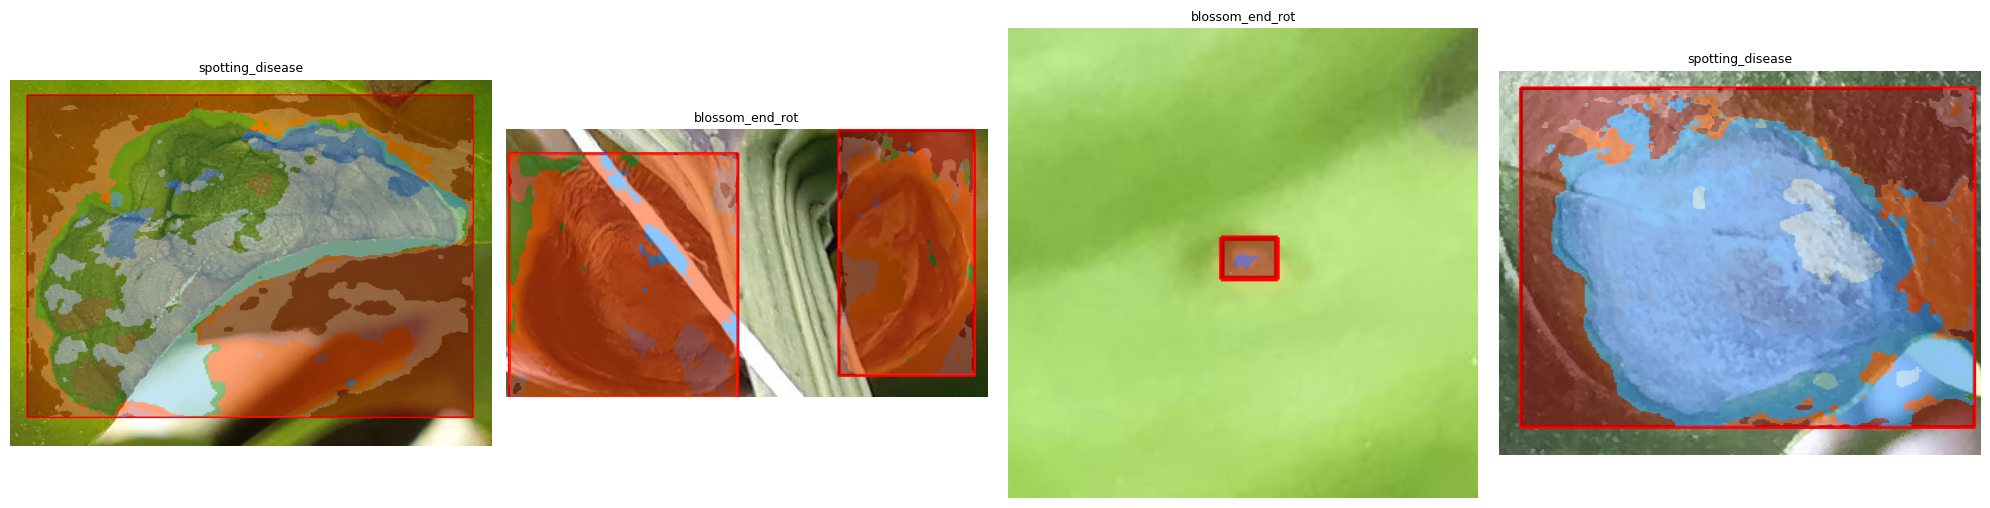

In [13]:
# ── Load frozen DDL ────────────────────────────────────────────────────────
def load_ddl(weights_path):
    cfg = get_cfg()
    cfg.merge_from_file(
        model_zoo.get_config_file('COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml'))
    cfg.MODEL.ROI_HEADS.NUM_CLASSES    = 6
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
    cfg.MODEL.WEIGHTS                 = weights_path
    return DefaultPredictor(cfg)


# Severity colour palette for visualisation (matches Figure 1D)
STAGE_COLORS = {
    0:  (0,   0,   0),    # background — black
    1:  (139, 0,   0),    # br1 — dark red
    2:  (205, 92,  92),   # br2 — indian red
    3:  (255, 69,  0),    # br3 — orange-red
    4:  (85,  107, 47),   # gm1 — dark olive
    5:  (34,  139, 34),   # gm2 — forest green
    6:  (255, 215, 0),    # pm1 — gold
    7:  (255, 165, 0),    # pm2 — orange
    8:  (0,   0,   205),  # cp1 — medium blue
    9:  (30,  144, 255),  # cp2 — dodger blue
    10: (135, 206, 235),  # cp3 — sky blue
    11: (0,   191, 255),  # cp4 — deep sky blue
}
INV_SEVERITY = {v: k for k, v in SEVERITY_MAP.items()}


def mask_to_color(mask_hw):
    """Convert (H,W) stage-index mask → (H,W,3) RGB colour image."""
    color = np.zeros((*mask_hw.shape, 3), dtype=np.uint8)
    for idx, rgb in STAGE_COLORS.items():
        color[mask_hw == idx] = rgb
    return color


def run_naive_pipeline(img_bgr, ddl_predictor, dsa_model,
                       device=DEVICE, score_thresh=0.5):
    """
    Full naïve two-stage inference (Figure 6).
    Prints descriptive phrases matching the format in Figure 14.
    Returns the annotated image (RGB).
    """
    dsa_model.eval()
    H, W      = img_bgr.shape[:2]
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay   = img_rgb.copy()

    # ── Stage 1: DDL (frozen) ──────────────────────────────────────────────
    with torch.no_grad():
        ddl_out   = ddl_predictor(img_bgr)
    instances = ddl_out['instances'].to('cpu')
    keep      = instances.scores >= score_thresh
    instances = instances[keep]

    if len(instances) == 0:
        print('No anomalies detected.')
        return img_rgb

    boxes   = instances.pred_boxes.tensor.numpy().astype(int)
    classes = instances.pred_classes.numpy()
    scores  = instances.scores.numpy()

    # ── Stage 2: DSA on each crop ──────────────────────────────────────────
    print('Disease Severity Analysis:')
    for det_id, (box, cls_id, score) in enumerate(zip(boxes, classes, scores)):
        cls_name = CLASS_NAMES[cls_id]

        # Draw DDL bounding box
        x1, y1, x2, y2 = np.clip(box, 0, [W, H, W, H])
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # Skip DSA for pest-only detections (Section 5.5)
        if cls_name in PEST_CLASSES:
            print(f'  {det_id}. {cls_name} detected. (conf: {score:.2f}) '
                  f'[no severity stages]')
            continue

        if x2 <= x1 or y2 <= y1:
            continue

        # Crop, resize to 256×256 (Section 4.2.2)
        crop     = img_rgb[y1:y2, x1:x2]
        crop_256 = cv2.resize(crop, (256, 256))
        crop_t   = torch.from_numpy(
            crop_256.transpose(2, 0, 1)
        ).float().unsqueeze(0).to(device) / 255.0

        with torch.no_grad():
            logits  = dsa_model(crop_t)                # (1, NSS, 256, 256)
        seg_256 = logits.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)

        # Resize segmentation mask back to original crop size
        seg_orig = cv2.resize(
            seg_256, (x2 - x1, y2 - y1),
            interpolation=cv2.INTER_NEAREST
        )

        # Blend colour mask onto overlay
        color_mask = mask_to_color(seg_orig)
        roi        = overlay[y1:y2, x1:x2]
        fg         = seg_orig > 0
        roi[fg]    = (0.5 * roi[fg] + 0.5 * color_mask[fg]).astype(np.uint8)

        # Dominant severity stage for the phrase
        flat        = seg_orig[seg_orig > 0]
        dom_stage   = int(np.bincount(flat).argmax()) if flat.size > 0 else 0
        stage_label = INV_SEVERITY.get(dom_stage, 'unknown')

        # Integration unit phrase (Figure 14 format)
        cx  = (x1 + x2) // 2
        cy  = (y1 + y2) // 2
        loc = (f"({'left' if cx < W//2 else 'right'}, "
               f"{'top' if cy < H//2 else 'bottom'})")
        print(f'  {det_id}. Stage {stage_label} {cls_name} detected '
              f'at {loc}. (conf: {score:.2f})')

    return overlay


# ── Run on a few test images ───────────────────────────────────────────────
ddl_predictor = load_ddl(DDL_WEIGHTS)

samples = random.sample(test_records, min(4, len(test_records)))
fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, rec in zip(axes, samples):
    img_bgr = cv2.imread(rec['img_path'])
    print(f"\n── {os.path.basename(rec['img_path'])} ──")
    result  = run_naive_pipeline(img_bgr, ddl_predictor, dsa_model)
    ax.imshow(result)
    ax.set_title(rec['class_name'], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DSA_OUTPUT, 'naive_pipeline_results.png'), dpi=150)
plt.show()